In [67]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


seismic_data = pd.read_csv('C:/Users/SH/Desktop/cleaned_seismic.csv')
seismic_data.head()
print(seismic_data.columns)

Index(['Seismic Zone', 'PGA (m/s²)', 'PGV (m/s)', 'PGD (m)',
       'Spectral Acceleration (g)', 'Soil Type', 'Site Amplification Factor',
       'Historical Earthquake Magnitude (Mw)', 'Fault Distance (km)',
       'Seismic Wave Frequency (Hz)', 'Building Height (m)',
       'Number of Stories', 'Structural Material', 'Foundation Type',
       'Natural Frequency (Hz)', 'Damping Ratio (%)', 'Mass of Structure (kg)',
       'Axial Stiffness (kN/m)', 'Bending Stiffness (kN·m²)',
       'Lateral Load Resisting System',
       'Predicted Max Inter-Story Drift Ratio (%)',
       'Predicted Max Roof Displacement (m)',
       'Predicted Base Shear Force (kN)',
       'Predicted Structural Acceleration (m/s²)',
       'Predicted Damage Index (0–1 Scale)',
       'Predicted Collapse Probability (%)', 'damage_index', 'collapse_prob',
       'collapse_risk'],
      dtype='object')


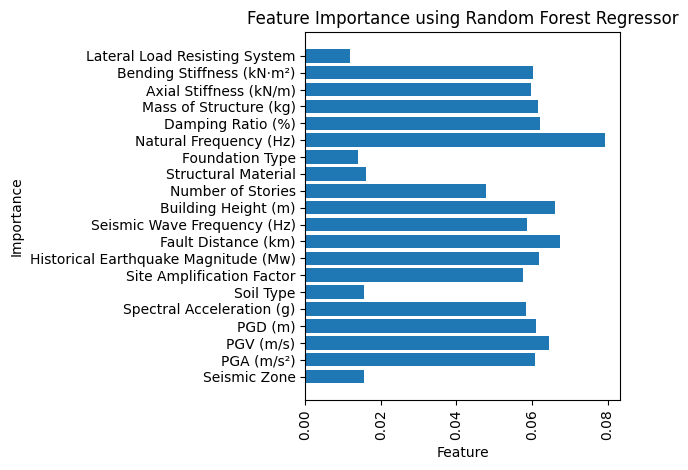

In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

x = seismic_data.drop(columns = ['Predicted Max Inter-Story Drift Ratio (%)','Predicted Max Roof Displacement (m)', 'Predicted Base Shear Force (kN)',
                                 'Predicted Structural Acceleration (m/s²)','Predicted Damage Index (0–1 Scale)','Predicted Collapse Probability (%)', 
                                 'damage_index', 'collapse_prob','collapse_risk'])
y = seismic_data['damage_index']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

randomforest = RandomForestRegressor(n_estimators = 500, random_state = 42)
randomforest.fit(x_train, y_train)

important_rf = randomforest.feature_importances_
feature_names = x.columns

plt.barh(feature_names, important_rf)
plt.xticks(rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance using Random Forest Regressor')
plt.tight_layout()
plt.show()


In [71]:
importantfeatures_rf = pd.Series(important_rf, index=feature_names)
for_rf = importantfeatures_rf.sort_values(ascending=False).head(7)
print(for_rf)

Natural Frequency (Hz)                  0.079337
Fault Distance (km)                     0.067311
Building Height (m)                     0.066204
PGV (m/s)                               0.064572
Damping Ratio (%)                       0.062096
Historical Earthquake Magnitude (Mw)    0.061828
Mass of Structure (kg)                  0.061575
dtype: float64


In [91]:
x = seismic_data[['Natural Frequency (Hz)','Fault Distance (km)','Building Height (m)', 'PGV (m/s)','Damping Ratio (%)', 
                  'Historical Earthquake Magnitude (Mw)', 'Mass of Structure (kg)']]
y = seismic_data['damage_index']  # continuous target

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train XGBoost Regressor
rf =RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

# Evaluate regression performance
print(f"R² Score: {r2_score(y_test, rf_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, rf_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.4f}")

R² Score: -0.0176
MAE: 0.2450
RMSE: 0.2872


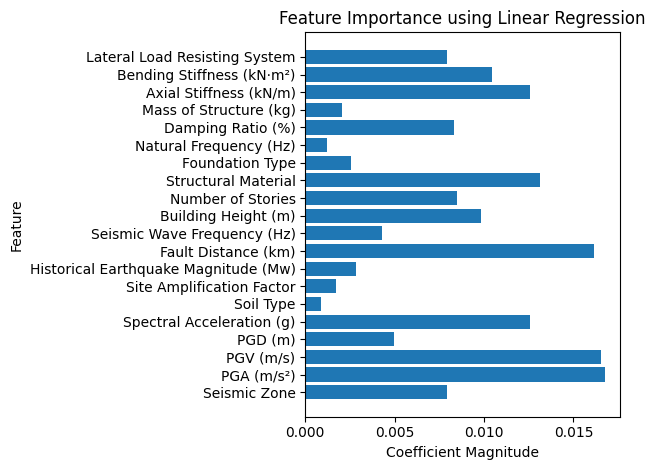

In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Split data
x = seismic_data.drop(columns=[
    'Predicted Max Inter-Story Drift Ratio (%)', 'Predicted Max Roof Displacement (m)', 
    'Predicted Base Shear Force (kN)', 'Predicted Structural Acceleration (m/s²)',
    'Predicted Damage Index (0–1 Scale)', 'Predicted Collapse Probability (%)', 
    'damage_index', 'collapse_prob', 'collapse_risk'
])
y = seismic_data['damage_index']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train Linear Regression
linreg = LinearRegression()
linreg.fit(x_train, y_train)

# Get coefficients as feature importance
importance_lin = np.abs(linreg.coef_)
feature_names = x.columns

# Plot feature importances
plt.barh(feature_names, importance_lin)
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.title('Feature Importance using Linear Regression')
plt.tight_layout()
plt.show()

In [102]:
importantfeatures_lin = pd.Series(importance_lin, index=feature_names)
for_lin = importantfeatures_lin.sort_values(ascending=False).head(7)
print(for_lin)

PGA (m/s²)                   0.016768
PGV (m/s)                    0.016547
Fault Distance (km)          0.016138
Structural Material          0.013137
Axial Stiffness (kN/m)       0.012564
Spectral Acceleration (g)    0.012545
Bending Stiffness (kN·m²)    0.010426
dtype: float64


In [106]:
x = seismic_data[['PGA (m/s²)','PGV (m/s)','Fault Distance (km)', 'Structural Material','Axial Stiffness (kN/m)', 
                  'Spectral Acceleration (g)', 'Bending Stiffness (kN·m²)']]
y = seismic_data['damage_index']  # continuous target

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train XGBoost Regressor
lin =LinearRegression()
lin.fit(x_train, y_train)
lin_pred = lin.predict(x_test)

# Evaluate regression performance
print(f"R² Score: {r2_score(y_test, lin_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, lin_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lin_pred)):.4f}")

R² Score: -0.0397
MAE: 0.2512
RMSE: 0.2903


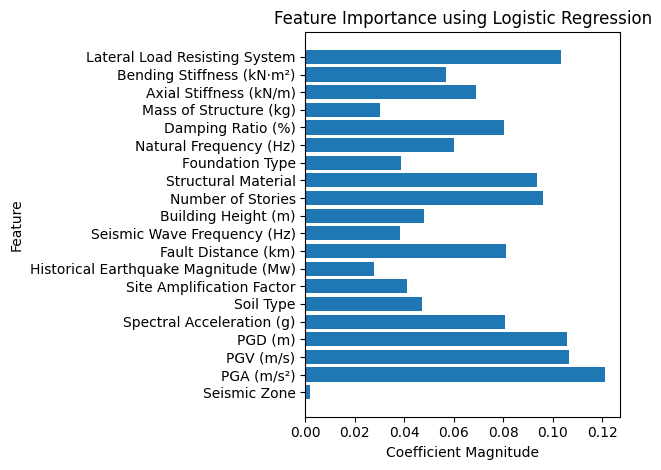

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Prepare features
x = seismic_data.drop(columns=[
    'Predicted Max Inter-Story Drift Ratio (%)', 'Predicted Max Roof Displacement (m)', 
    'Predicted Base Shear Force (kN)', 'Predicted Structural Acceleration (m/s²)',
    'Predicted Damage Index (0–1 Scale)', 'Predicted Collapse Probability (%)', 
    'damage_index', 'collapse_prob', 'collapse_risk'
])

# Create binary target: 1 if damage_index > 0.5 else 0
y = (seismic_data['damage_index'] > 0.5).astype(int)

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train logistic regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)

# Get feature importances (absolute coefficients)
importance_log = np.abs(logreg.coef_[0])
feature_names = x.columns

# Plot feature importance
plt.barh(feature_names, importance_log)
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.title('Feature Importance using Logistic Regression')
plt.tight_layout()
plt.show()

In [109]:
importantfeatures_log = pd.Series(importance_log, index=feature_names)
for_log = importantfeatures_log.sort_values(ascending=False).head(7)
print(for_log)

PGA (m/s²)                       0.121157
PGV (m/s)                        0.106572
PGD (m)                          0.105649
Lateral Load Resisting System    0.103204
Number of Stories                0.095924
Structural Material              0.093645
Fault Distance (km)              0.081158
dtype: float64


              precision    recall  f1-score   support

         Low       0.35      0.33      0.34        54
    Moderate       0.21      0.17      0.19        40
        High       0.13      0.11      0.12        44
   Very High       0.25      0.31      0.28        62

    accuracy                           0.24       200
   macro avg       0.23      0.23      0.23       200
weighted avg       0.24      0.24      0.24       200



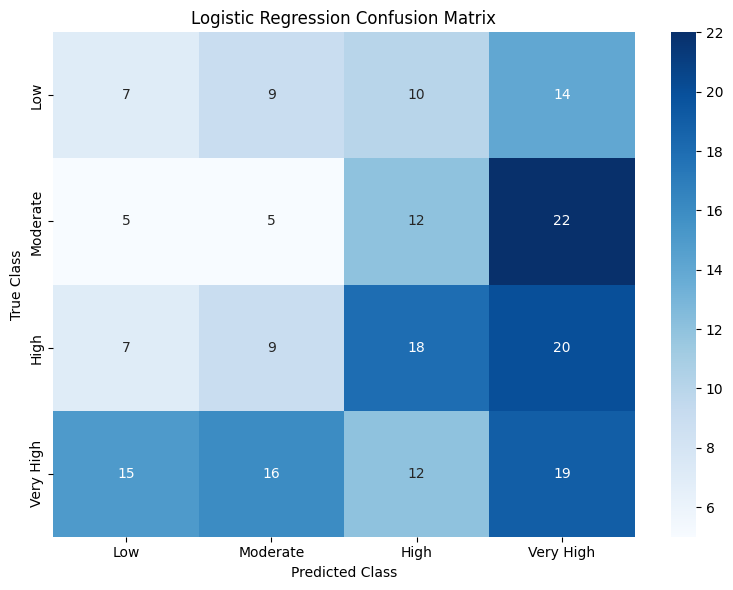

In [117]:
bins = [0, 0.25, 0.5, 0.75, 1.0]
label_names = ['Low', 'Moderate', 'High', 'Very High']

# Prepare features
x = seismic_data[['PGA (m/s²)','PGV (m/s)','PGD (m)', 'Lateral Load Resisting System',
                  'Number of Stories', 'Structural Material', 'Fault Distance (km)']]

# Convert continuous damage_index into classes
y = pd.cut(seismic_data['damage_index'], bins=bins, labels=label_names, include_lowest=True)

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize logistic regression and train
logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)

# Predict on test set
log_pred = logreg.predict(x_test)

print(classification_report(y_test, log_pred, target_names=label_names))

# Compute confusion matrix
cm = confusion_matrix(y_test, log_pred, labels=label_names)

# Plot confusion matrix heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()


c:\Users\SH\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:34:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


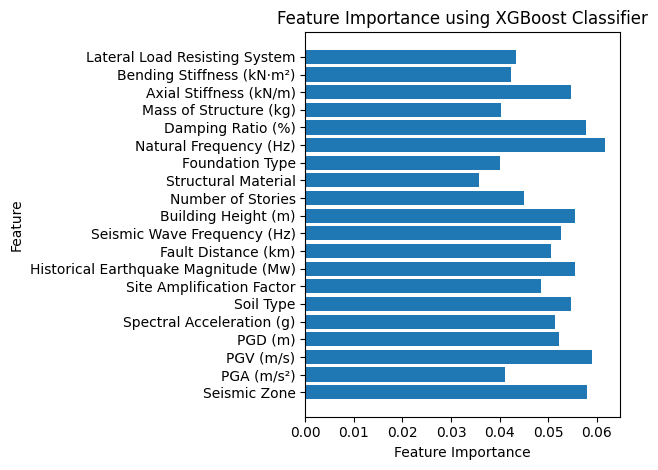

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Prepare features
x = seismic_data.drop(columns=[
    'Predicted Max Inter-Story Drift Ratio (%)', 'Predicted Max Roof Displacement (m)', 
    'Predicted Base Shear Force (kN)', 'Predicted Structural Acceleration (m/s²)',
    'Predicted Damage Index (0–1 Scale)', 'Predicted Collapse Probability (%)', 
    'damage_index', 'collapse_prob', 'collapse_risk'
])

# Binary target: damage_index > 0.5
y = (seismic_data['damage_index'] > 0.5).astype(int)

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize XGBoost classifier
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train model
model.fit(x_train, y_train)

# Get feature importances
importance_xgb = model.feature_importances_
feature_names = x.columns

# Plot feature importances
plt.barh(feature_names, importance_xgb)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance using XGBoost Classifier')
plt.tight_layout()
plt.show()

In [ ]:
importantfeatures_xgb = pd.Series(importance_xgb, index=feature_names)
for_xgb = importantfeatures_xgb.sort_values(ascending=False).head(7)
print(for_xgb)

Natural Frequency (Hz)                  0.061675
PGV (m/s)                               0.058951
Seismic Zone                            0.058020
Damping Ratio (%)                       0.057729
Building Height (m)                     0.055584
Historical Earthquake Magnitude (Mw)    0.055553
Soil Type                               0.054714
dtype: float32


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Features and target
x = seismic_data[['Natural Frequency (Hz)','PGV (m/s)','Seismic Zone', 'Damping Ratio (%)','Building Height (m)', 
                  'Historical Earthquake Magnitude (Mw)', 'Soil Type']]
y = seismic_data['damage_index']  # continuous target

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train XGBoost Regressor
xgb = XGBRegressor(objective='reg:squarederror', n_estimators=300, learning_rate=0.05, random_state=42)
xgb.fit(x_train, y_train)

# Predictions
xgb_pred = xgb.predict(x_test)

# Evaluate regression performance
print(f"R² Score: {r2_score(y_test, xgb_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, xgb_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred)):.4f}")


R² Score: -0.1817
MAE: 0.2614
RMSE: 0.3095


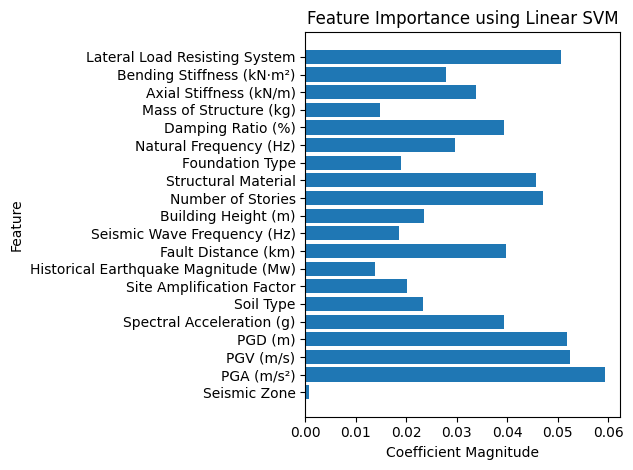

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Prepare features
x = seismic_data.drop(columns=[
    'Predicted Max Inter-Story Drift Ratio (%)', 'Predicted Max Roof Displacement (m)', 
    'Predicted Base Shear Force (kN)', 'Predicted Structural Acceleration (m/s²)',
    'Predicted Damage Index (0–1 Scale)', 'Predicted Collapse Probability (%)', 
    'damage_index', 'collapse_prob', 'collapse_risk'
])

# Binary target: damage_index > 0.5
y = (seismic_data['damage_index'] > 0.5).astype(int)

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize linear SVM
svm = LinearSVC(max_iter=10000, random_state=42)
svm.fit(x_train, y_train)

# Get absolute value of coefficients as feature importance
importance_svm = np.abs(svm.coef_[0])
feature_names = x.columns

# Plot feature importances
plt.barh(feature_names, importance_svm)
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.title('Feature Importance using Linear SVM')
plt.tight_layout()
plt.show()

In [ ]:
importantfeatures_svm = pd.Series(importance_svm, index=feature_names)
for_svm = importantfeatures_svm.sort_values(ascending=False).head(7)
print(for_svm)

PGA (m/s²)                       0.059316
PGV (m/s)                        0.052296
PGD (m)                          0.051705
Lateral Load Resisting System    0.050587
Number of Stories                0.047063
Structural Material              0.045635
Fault Distance (km)              0.039642
dtype: float64


In [ ]:
from sklearn.svm import SVR

x = seismic_data[['PGA (m/s²)','PGV (m/s)','PGD (m)', 'Lateral Load Resisting System','Number of Stories', 
                  'Structural Material', 'Fault Distance (km)']]
y = seismic_data['damage_index']  # continuous target


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

svm_model = SVR(kernel='rbf')  
svm_model.fit(x_train, y_train)
svm_pred = svm_model.predict(x_test)

print("SVM Regression Results:")
print(f"R^2 Score: {r2_score(y_test, svm_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, svm_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, svm_pred)):.4f}")

SVM Regression Results:
R^2 Score: -0.2251
MAE: 0.2671
RMSE: 0.3151


In [ ]:
bins = [0, 0.25, 0.5, 0.75, 1.0]
label_names = ['Low', 'Moderate', 'High', 'Very High']

y_test_clipped = np.clip(y_test, 0, 1)
svm_pred_clipped = np.clip(svm_pred, 0, 1)
xgb_pred_clipped = np.clip(xgb_pred, 0, 1)


y_test_classes = np.digitize(y_test_clipped, bins, right=True) - 1
svm_pred_classes = np.digitize(svm_pred_clipped, bins, right=True) - 1
xgb_pred_classes = np.digitize(xgb_pred_clipped, bins, right=True) - 1

y_test_classes = np.clip(y_test_classes, 0, len(bins) - 2)
svm_pred_classes = np.clip(svm_pred_classes, 0, len(bins) - 2)
xgb_pred_classes = np.clip(xgb_pred_classes, 0, len(bins) - 2)

XGBoost Classification Report:
[[ 0 19 18  3]
 [ 1 16 24  3]
 [ 3 20 30  1]
 [ 1 24 35  2]]
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        40
    Moderate       0.20      0.36      0.26        44
        High       0.28      0.56      0.37        54
   Very High       0.22      0.03      0.06        62

    accuracy                           0.24       200
   macro avg       0.18      0.24      0.17       200
weighted avg       0.19      0.24      0.18       200



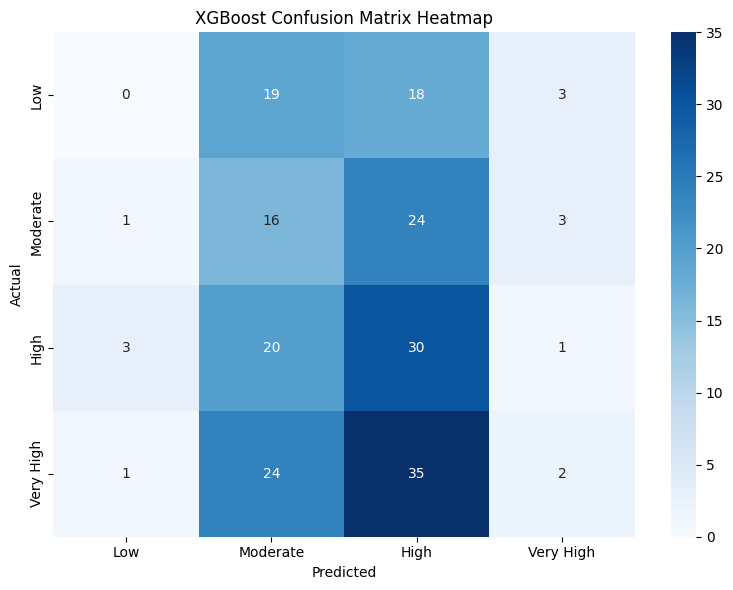

In [ ]:
print("XGBoost Classification Report:")

# Compute confusion matrix
cm = confusion_matrix(y_test_classes, xgb_pred_classes)
print(cm)

# Print classification report
print(classification_report(
    y_test_classes,
    xgb_pred_classes,
    labels=[0, 1, 2, 3],
    target_names=label_names,
    zero_division=0
))

# Plot confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()


SVM Classification Report:
[[ 1 15 22  2]
 [ 2 20 21  1]
 [ 0 25 27  2]
 [ 1 22 37  2]]
              precision    recall  f1-score   support

         Low       0.25      0.03      0.05        40
    Moderate       0.24      0.45      0.32        44
        High       0.25      0.50      0.34        54
   Very High       0.29      0.03      0.06        62

    accuracy                           0.25       200
   macro avg       0.26      0.25      0.19       200
weighted avg       0.26      0.25      0.19       200



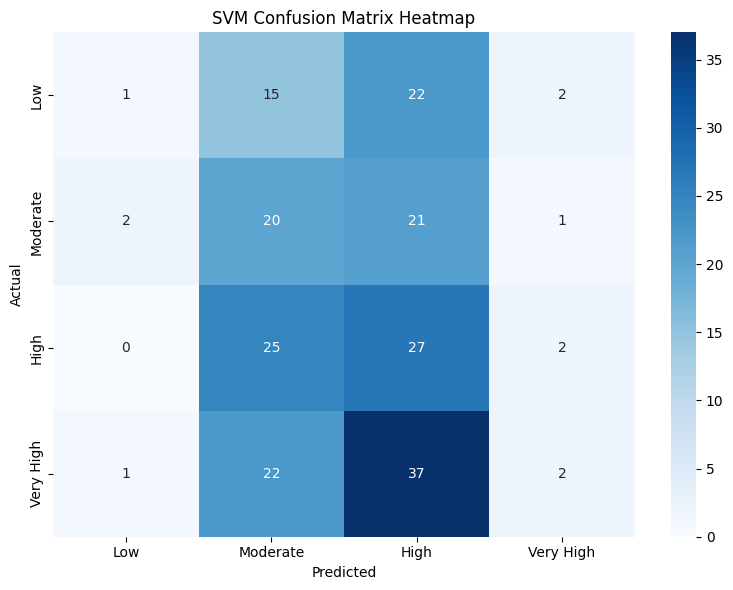

In [90]:
print("\nSVM Classification Report:")
cm = confusion_matrix(y_test_classes, svm_pred_classes)
print(cm)
print(classification_report(
    y_test_classes,
    svm_pred_classes,
    labels=[0, 1, 2, 3],
    target_names=label_names,
    zero_division=0
))

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()